# Objective

* plot recent data and see if it came in and looks ok
  * do that for the raw.netcdf files!!
* check if the langleys look usable

# Imports

In [1]:
#import helpers
import numpy as np
import pathlib as pl
from importlib import reload
from qclib import by_date


In [2]:
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
import atmPy.data_archives.NOAA_ESRL_GMD_GRAD.surfrad.surfrad as srf

# MFRSR vs braodband

In [16]:
# Settings
####
pattern = '*.nc'
site = 'bon'
p2fld = '/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/raw.netcdf/v0.3/2020/'
p2fldtest = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020/bnd_mfrsr_raw_20200101.nc')
p2fldt = pl.Path(p2fld.format(site=site))

p2fldsrf ="/Volumes/grad/surfrad/products_level1/radiation_netcdf/v1.1/{site}/2020/"
patternsfr = '*_2020*.nc'
p2fldsrftest = pl.Path('/Volumes/grad/surfrad/products_level1/radiation_netcdf/v1.1/bon/2020/srf_rad_full_bon_20200309.nc')
p2fldsrft = pl.Path(p2fldsrf.format(site=site))

In [17]:
# uwe = p2fldsrft.glob(patternsfr)
# next(uwe)

In [18]:
def path2date(path2file):
    """
    Takes path to file and converts to date. Needs adjustment for individual
    circumstances.
    """
    return pd.to_datetime(path2file.name.split('_')[3].split('.')[0])
path2date(p2fldtest)

def path2datesrf(path2file):
    """
    Takes path to file and converts to date. Needs adjustment for individual
    circumstances.
    """
    return pd.to_datetime(path2file.name.split('_')[4].split('.')[0])
path2datesrf(p2fldsrftest)

def read_data(path2file):
    """
    Takes the path to the file and returns an object that the
    plot function can turn into a plot. Needs ajustment for individual
    circumstances"""
    ds = xr.open_dataset(path2file)
    # ds = ds.sel(channel = [415, 500, 670, 870, 1625])
    return ds

In [19]:
# test path2date and read_data
# path2file = next(p2fldsrft.glob(patternsfr))
dssrf = read_data(p2fldsrftest)

In [20]:
ds = read_data(p2fldtest)

In [21]:
# bla = read_data()

In [48]:
def plot_global(data_object, a):
    # for daob in data_object:
    ds = data_object['mfrsr']
    ds.global_horizontal.sel(channel = 2).plot(ax=a, add_legend=False)
    a.set_ylabel(site)
    # dt = pd.to_datetime(ds.datetime.values[0])
    # a.set_title(f'{ds.site} -- {dt.year:04d}-{dt.month:02d}-{dt.day:02d}')
    # a.legend().remove()
    # at = a.twinx()
    dssrf = data_object['srf']
    dssrf.dw_solar.plot(ax = a, color = 'black')

# test

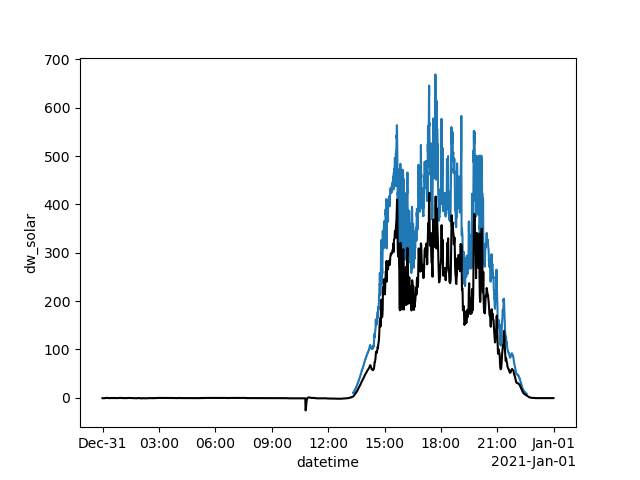

In [49]:
# dato = {'data': bla}
f,a = plt.subplots()
# plot_global({'mfrsr': ds,
#              'srf': dssrf}, a)

plot_global(data_object, a)
plt.gcf().show()

In [50]:
cont.view.plot.a.clear()

In [51]:
cont.view.plot.f.canvas.draw()

### do it

In [52]:
reload(by_date)

<module 'qclib.by_date' from '/Users/htelg/prog/qclib/qclib/by_date.py'>

In [53]:
%matplotlib widget

In [54]:
sites = ['bon']
print(p2fld.format(site=site))
path2datafolder = [['mfrsr', p2fld.format(site='bnd'), read_data, path2date, pattern],
                   ['srf', p2fldsrf.format(site='bon'), read_data, path2datesrf, patternsfr],
                  ]
                 
                  
plot_function = {'global': plot_global,
                 # 'aod': plot_aod,
                }

# plot_function = {site: lambda data, a: plot_global(data, a, site) for site in sites}
gridspec_kwargs = {'hspace': 0}
data = by_date.Data(path2datafolder,
                    plot_function,
                    gridspec_kwargs=gridspec_kwargs,
                    verbose = True)
data_object = data.active_data
# ds = data_object['bnd']
# data.plot()


/Volumes/grad/Inst/MFR/SURFRAD/bon/mfrsr/raw.netcdf/v0.3/2020/
Test if path2date and the load data functions work
------
trying to open file at /Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020/bnd_mfrsr_raw_20200424.nc ... done
path2date_function returns: 2020-04-24 00:00:00
------
trying to open file at /Volumes/grad/surfrad/products_level1/radiation_netcdf/v1.1/bon/2020/srf_rad_full_bon_20200309.nc ... done
path2date_function returns: 2020-03-09 00:00:00
Found 366 files for folder /Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020 (dataset: mfrsr)
Found 366 files for folder /Volumes/grad/surfrad/products_level1/radiation_netcdf/v1.1/bon/2020 (dataset: srf)
366 valid dates found spanning from 2020-01-01 00:00:00 to 2020-12-31 00:00:00


In [55]:
cont = by_date.Controller(data = data,#Data('/mnt/telg/data/grad/surfrad/aod1625/0.4/tbl/2020/', read_data, plot_data),                        
                        # path2database=path2database,
                        # database_table_name_base='vis_nsascience_quicklooks',
                         )

In [56]:
cont.view.controlls.initiate()

date picker changed to 2020-12-31 00:00:00


In [57]:
out = cont.view.plot.initiate()

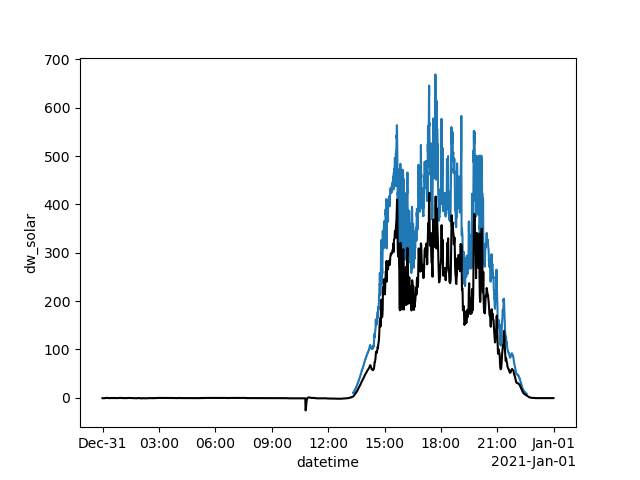

In [58]:
f = plt.gcf()
f.show()

In [19]:
cont.data.active_data

{'mfrsr': <xarray.Dataset> Size: 996kB
 Dimensions:             (datetime: 4294, channel: 7)
 Coordinates:
   * datetime            (datetime) datetime64[ns] 34kB 2020-12-31 ... 2020-12...
   * channel             (channel) int64 56B 0 1 2 3 4 5 6
 Data variables:
     alltime             (datetime, channel) float64 240kB ...
     global_horizontal   (datetime, channel) float64 240kB ...
     diffuse_horizontal  (datetime, channel) float64 240kB ...
     direct_horizontal   (datetime, channel) float64 240kB ...
 Attributes: (12/23)
     instrument:         mfrsr
     start_time:         2020-12-30 19:04:40
     avg_period:         20
     sample_rate:        20
     logger_id:          $377D
     head_id:            $DAB8
     ...                 ...
     site:               bnd
     site_name:          Bondville
     elevation:          230
     sn_mfrsr:           672
     parent_files:       /Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw/2020/bnd...
     day_complete:       True,
 'sr

# data comming in at all sites?

In [45]:
# Settings
####
pattern = '*.nc'
site = 'bnd'
p2fld = '/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/raw.netcdf/v0.3/2020/'
p2fldtest = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020/bnd_mfrsr_raw_20200101.nc')
p2fldt = pl.Path(p2fld.format(site=site))

In [78]:
def path2date(path2file):
    """
    Takes path to file and converts to date. Needs adjustment for individual
    circumstances.
    """
    return pd.to_datetime(path2file.name.split('_')[3].split('.')[0])

def read_data(path2file):
    """
    Takes the path to the file and returns an object that the
    plot function can turn into a plot. Needs ajustment for individual
    circumstances"""
    ds = xr.open_dataset(path2file)
    # ds = ds.sel(channel = [415, 500, 670, 870, 1625])
    return ds

def plot_data(data_object, a):
    ds = data_object['bla']
    variable = 'aod'
    selection = {'channel': 500}
    ds[variable].sel(selection).plot()

In [47]:
# test path2date and read_data
path2file = next(p2fldt.glob(pattern))
bla = read_data(path2file)
path2date(p2fldtest), path2file

(Timestamp('2020-01-01 00:00:00'),
 PosixPath('/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020/bnd_mfrsr_raw_20200424.nc'))

In [112]:
def plot_global(data_object, a, site):
    # for daob in data_object:
    ds = data_object[site]
    ds.global_horizontal.sel(channel = 2).plot(ax=a, add_legend=False)
    a.set_ylabel(site)
    dt = pd.to_datetime(ds.datetime.values[0])
    a.set_title(f'{ds.site} -- {dt.year:04d}-{dt.month:02d}-{dt.day:02d}')
    # a.legend().remove()

# test

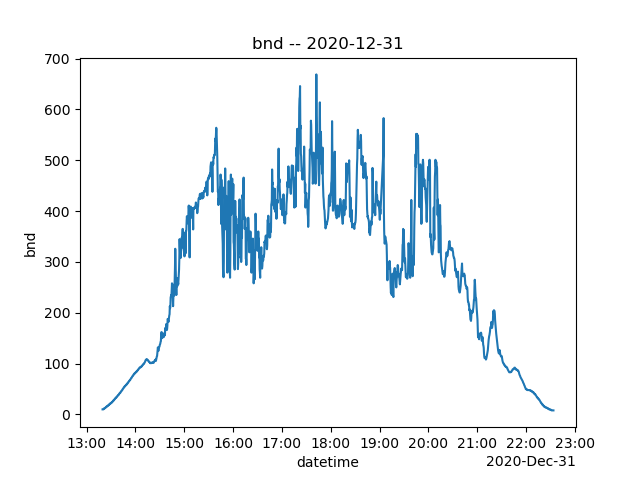

In [119]:
# dato = {'data': bla}
f,a = plt.subplots()
# plot_global({'bnd': ds}, a, 'bnd')
plot_function['bnd']({'bnd': ds},a)
plt.gcf().show()

### do it

In [105]:
reload(by_date)

<module 'qclib.by_date' from '/Users/htelg/prog/qclib/qclib/by_date.py'>

In [106]:
%matplotlib widget

In [120]:
sites = ['bnd']
print(p2fld.format(site=site))
# path2datafolder = [[site, p2fld.format(site='bnd'), read_data, path2date, pattern],
#                    # ['aod_bnd', p2fld.format(site='bnd'), read_data, path2date, pattern],
#                   ]

path2datafolder = [[site, p2fld.format(site=site), read_data, path2date, pattern] for site in sites]
                  
                  
# plot_function = {'global': plot_global,
#                  # 'aod': plot_aod,
#                 }

plot_function = {site: lambda data, a: plot_global(data, a, site) for site in sites}
gridspec_kwargs = {'hspace': 0}
data = by_date.Data(path2datafolder,
                    plot_function,
                    gridspec_kwargs=gridspec_kwargs,
                    verbose = True)
data_object = data.active_data
ds = data_object['bnd']
# data.plot()


/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020/
Test if path2date and the load data functions work
------
trying to open file at /Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020/bnd_mfrsr_raw_20200424.nc ... done
path2date_function returns: 2020-04-24 00:00:00
Found 366 files for folder /Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020 (dataset: bnd)
366 valid dates found spanning from 2020-01-01 00:00:00 to 2020-12-31 00:00:00


In [121]:
cont = by_date.Controller(data = data,#Data('/mnt/telg/data/grad/surfrad/aod1625/0.4/tbl/2020/', read_data, plot_data),                        
                        # path2database=path2database,
                        # database_table_name_base='vis_nsascience_quicklooks',
                         )

In [122]:
cont.view.controlls.initiate()

date picker changed to 2020-12-31 00:00:00


In [123]:
out = cont.view.plot.initiate()

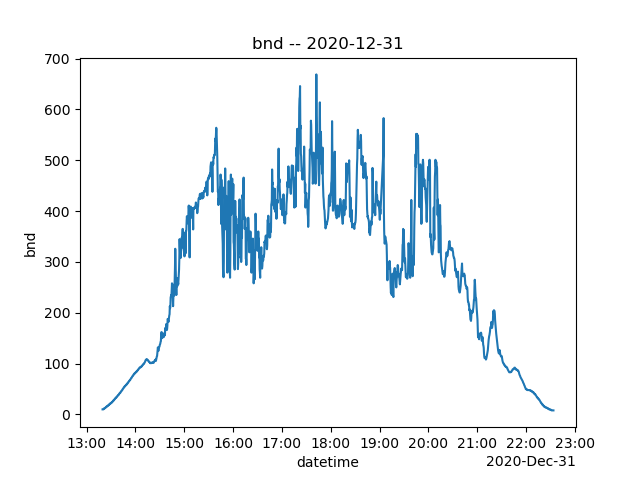

In [124]:
f = plt.gcf()
f.show()

# All channels at a single site

In [45]:
# Settings
####
pattern = '*.nc'
site = 'bnd'
p2fld = '/Volumes/grad/Inst/MFR/SURFRAD/{site}/mfrsr/raw.netcdf/v0.3/2020/'
p2fldtest = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020/bnd_mfrsr_raw_20200101.nc')
p2fldt = pl.Path(p2fld.format(site=site))

In [46]:
def path2date(path2file):
    """
    Takes path to file and converts to date. Needs adjustment for individual
    circumstances.
    """
    return pd.to_datetime(path2file.name.split('_')[3].split('.')[0])

def read_data(path2file):
    """
    Takes the path to the file and returns an object that the
    plot function can turn into a plot. Needs ajustment for individual
    circumstances"""
    ds = xr.open_dataset(path2file)
    # ds = ds.sel(channel = [415, 500, 670, 870, 1625])
    return ds


def plot_data(data_object, a):
    ds = data_object['bla']
    variable = 'aod'
    selection = {'channel': 500}
    ds[variable].sel(selection).plot()

In [47]:
# test path2date and read_data
path2file = next(p2fldt.glob(pattern))
bla = read_data(path2file)
path2date(p2fldtest), path2file

(Timestamp('2020-01-01 00:00:00'),
 PosixPath('/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020/bnd_mfrsr_raw_20200424.nc'))

In [30]:
def plot_global(data_object, a):
    # for daob in data_object:
    ds = data_object['data']
    ds.global_horizontal.plot.line(x='datetime', ax=a, add_legend=False)
    a.set_ylabel('global')
    dt = pd.to_datetime(ds.datetime.values[0])
    a.set_title(f'{ds.site} -- {dt.year:04d}-{dt.month:02d}-{dt.day:02d}')
    # a.legend().remove()


def plot_diff(data_object, a):
    ds = data_object['data']
    ds.diffuse_horizontal.plot.line(x='datetime', ax=a, add_legend=False)
    a.set_ylabel('diffuse')


def plot_direct(data_object, a):
    ds = data_object['data']
    ds.direct_horizontal.plot.line(x='datetime', ax=a, add_legend=True)
    a.set_ylabel('direct')

# test

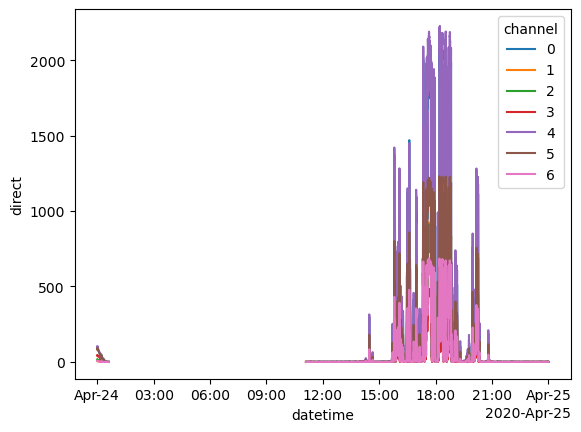

In [31]:
dato = {'data': bla}
f,a = plt.subplots()
# plot_global(dato, a)
plot_direct(dato, a)
# plot_global(dato, a)

### do it

In [39]:
# path2database = ''

In [34]:
# sites = (s.abb.lower() for s in srf.network.stations.list)

In [66]:
reload(by_date)

<module 'qclib.by_date' from '/Users/htelg/prog/qclib/qclib/by_date.py'>

In [75]:
%matplotlib widget

In [71]:
# site = next(sites)
site = 'bnd'
if site == 'fpk': site = 'fpe'
print(site)
print(p2fld.format(site=site))
path2datafolder = [['data', p2fld.format(site=site), read_data, path2date, pattern],
                   # ['aod_bnd', p2fld.format(site='bnd'), read_data, path2date, pattern],
                  ]
plot_function = {'global': plot_global,
                 'diffuse': plot_diff,
                 'direct': plot_direct,
                 # 'aod': plot_aod,
                }
gridspec_kwargs = {'hspace': 0}
data = by_date.Data(path2datafolder,
                    plot_function,
                    gridspec_kwargs=gridspec_kwargs,
                    verbose = True)
data_object = data.active_data
ds = data_object['data']
# data.plot()
assert(ds.site == site)

bnd
/Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020/
Test if path2date and the load data functions work
------
trying to open file at /Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020/bnd_mfrsr_raw_20200424.nc ... done
path2date_function returns: 2020-04-24 00:00:00
Found 366 files for folder /Volumes/grad/Inst/MFR/SURFRAD/bnd/mfrsr/raw.netcdf/v0.3/2020 (dataset: data)
366 valid dates found spanning from 2020-01-01 00:00:00 to 2020-12-31 00:00:00


In [73]:
cont = by_date.Controller(data = data,#Data('/mnt/telg/data/grad/surfrad/aod1625/0.4/tbl/2020/', read_data, plot_data),                        
                        # path2database=path2database,
                        # database_table_name_base='vis_nsascience_quicklooks',
                         )

In [74]:
cont.view.controlls.initiate()

date picker changed to 2020-12-31 00:00:00


In [76]:
out = cont.view.plot.initiate()

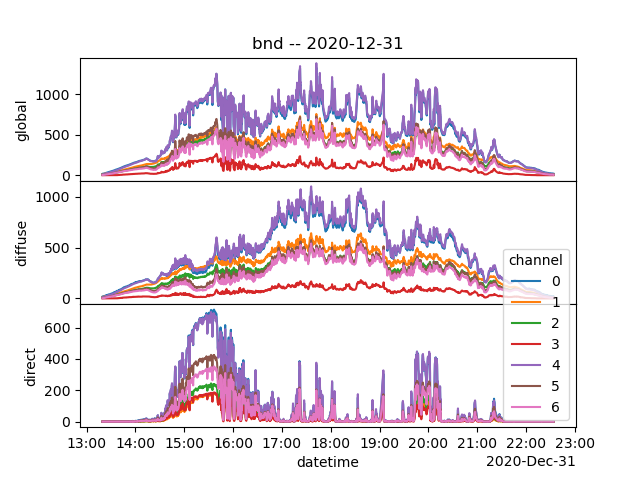

In [77]:
f = plt.gcf()
f.show()

In [ ]:
v